In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import datetime as dt
from datetime import datetime
import os
import kagglehub

# Change directory to the data location
os.chdir('../../ml_data')

# Read the data
df = pd.read_csv('credit_card_fraud_dataset.csv')
df

/Users/davidal-gurnawi/Documents/data_science/machine_learning/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0
...,...,...,...,...,...,...,...
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0


In [23]:
# Some data formatting
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

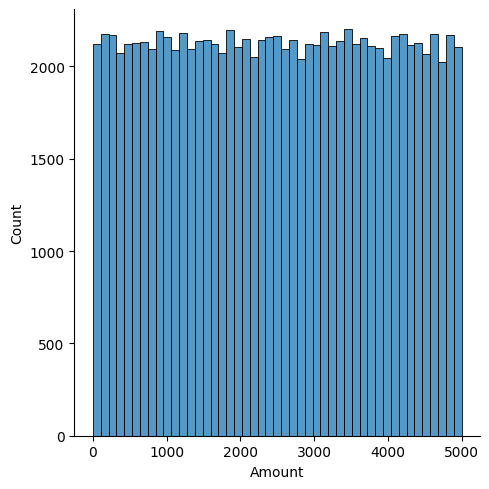

In [3]:
# Let's explore the amounts.
# Is there perhaps some pattern to the amounts at which fraud occurs?

sns.displot(data=df, x='Amount')

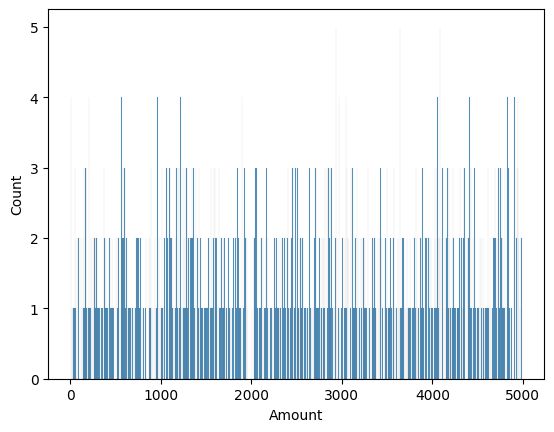

In [9]:
# The data overall seems to have an even spread
# What about if we look at purely fraud data?
ax = sns.histplot(data=df[df['IsFraud']==1], x='Amount', bins = 1000)

In [21]:
# Use np.histogram to obtain data
overview = np.histogram(df[df['IsFraud']==1]['Amount'], bins = range(0,1010,10))
overview

(array([4, 1, 1, 2, 1, 4, 2, 0, 2, 2, 0, 2, 1, 0, 3, 4, 4, 6, 2, 1, 5, 2,
        1, 2, 2, 1, 4, 3, 4, 3, 2, 3, 0, 0, 1, 1, 0, 5, 3, 3, 2, 2, 0, 2,
        2, 1, 3, 2, 0, 0, 2, 1, 2, 3, 0, 1, 4, 4, 4, 5, 3, 3, 0, 1, 2, 2,
        2, 0, 1, 1, 1, 1, 1, 3, 3, 3, 1, 3, 0, 1, 2, 0, 1, 2, 0, 0, 0, 4,
        3, 3, 1, 1, 0, 3, 0, 2, 5, 0, 2, 1]),
 array([   0,   10,   20,   30,   40,   50,   60,   70,   80,   90,  100,
         110,  120,  130,  140,  150,  160,  170,  180,  190,  200,  210,
         220,  230,  240,  250,  260,  270,  280,  290,  300,  310,  320,
         330,  340,  350,  360,  370,  380,  390,  400,  410,  420,  430,
         440,  450,  460,  470,  480,  490,  500,  510,  520,  530,  540,
         550,  560,  570,  580,  590,  600,  610,  620,  630,  640,  650,
         660,  670,  680,  690,  700,  710,  720,  730,  740,  750,  760,
         770,  780,  790,  800,  810,  820,  830,  840,  850,  860,  870,
         880,  890,  900,  910,  920,  930,  940,  950,  960,  970

In [22]:
counts = [p.get_height() for p in ax.patches]
bin_lefts = [p.get_x() for p in ax.patches]
bin_widths = [p.get_width() for p in ax.patches]

bin_centers = [x + w/2 for x, w in zip(bin_lefts, bin_widths)] # We get the middle values of the bins here

hist_df = pd.DataFrame({
    "bin_center": bin_centers,
    "count": counts
})
print(hist_df)

     bin_center  count
0       8.05016      4
1      13.03048      0
2      18.01080      1
3      22.99112      0
4      27.97144      1
..          ...    ...
995  4963.46856      0
996  4968.44888      1
997  4973.42920      0
998  4978.40952      2
999  4983.38984      2

[1000 rows x 2 columns]


<Axes: xlabel='TransactionDate', ylabel='Amount'>

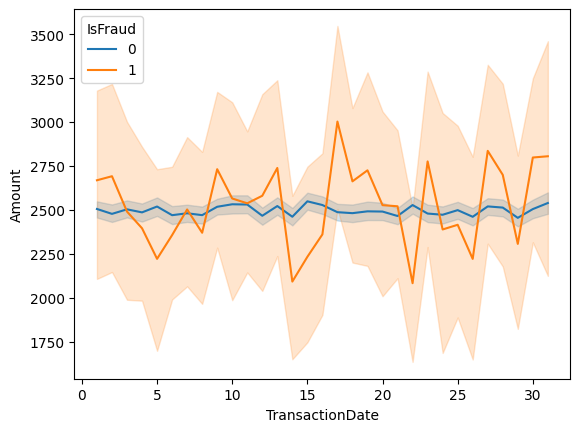

In [25]:
# We know that there distrubition of all the data is generally even
sns.lineplot(df, x=df.TransactionDate.dt.day, y= df.Amount, hue='IsFraud')

<Axes: xlabel='TransactionDate', ylabel='Amount'>

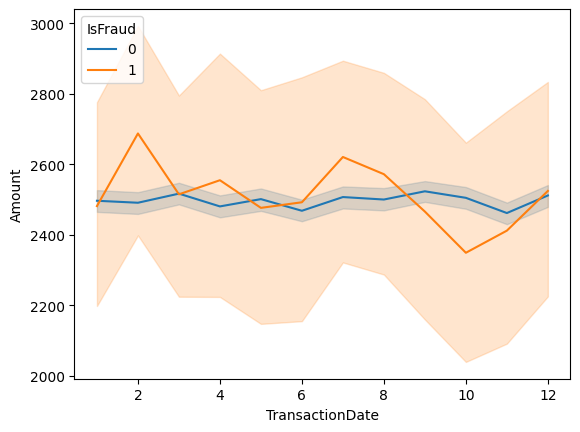

In [26]:
# We know that there distrubition of all the data is generally even
sns.lineplot(df, x=df.TransactionDate.dt.month, y= df.Amount, hue='IsFraud')

In [ ]:
# This is very interesting, because it tells us that non-fraudulent transactions are generally within a narrow bandwidth,
# whereas fraudulent transactions are all over the place we can create a classifier that increases the risk criterion,
# if the amount is outside of the trendlines.
# This means we will need to specify a max-min for each day/month for historic non-fraudulent transactions